# Test grafico di `metricEuclidean`
- $V_0 < 0$: collision
- $V_0 > 0$: no collision
- $V_0 = 0$: contact

In [1]:
from pathlib import Path
import sys

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# Permette di eseguire il notebook sia dalla radice del progetto sia da tests/.
project_root = Path.cwd()
if not (project_root / "hj_reachability").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from hj_reachability import Grid, sets
from hj_reachability.vehicle.geometry import build_terminal_set_boundary
from hj_reachability.vehicle.metrics import metricEuclidean

## 1. 6D grid

$$z = [x_{rel}, y_{rel}, \theta_{rel}, v_H, \delta_E, v_E].$$

In [2]:
grid = Grid.from_lattice_parameters_and_boundary_conditions(
    domain=sets.Box(
        lo=jnp.array([ -8.0, -6.0, -0.25 * np.pi,  1.0, -np.pi/12, 1.0]),
        hi=jnp.array([ 17.0,  6.0,  0.25 * np.pi, 11.0,  np.pi/12, 11.0]),
    ),
    shape=(26, 13, 15, 11, 11, 11),
    periodic_dims=2,
)

print("Ordine dello stato: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]")
print("Forma della griglia:", grid.shape)
print("Numero totale di stati:", int(np.prod(grid.shape)))

Ordine dello stato: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]
Forma della griglia: (26, 13, 15, 11, 11, 11)
Numero totale di stati: 6748170


## 2. Terminal set boundary and metric evaluation

In [3]:
boundary = build_terminal_set_boundary(
    n_theta=90,
    n_phi=180,
)

result = metricEuclidean(
    grid=grid,
    boundary=boundary,
)

V0 = np.asarray(result.terminal_values)

print("Forma di V0:", V0.shape)
print(f"Intervallo di V0: [{V0.min():.3f}, {V0.max():.3f}]")
print(f"Scala angolare s_theta: {result.angular_scale:.3f} m/rad")
print("Tutti i punti sono validi:", bool(np.asarray(result.valid).all()))

Forma di V0: (26, 13, 15, 11, 11, 11)
Intervallo di V0: [-3.204, 13.482]
Scala angolare s_theta: 5.738 m/rad
Tutti i punti sono validi: True


## 3. Slice scatter plot

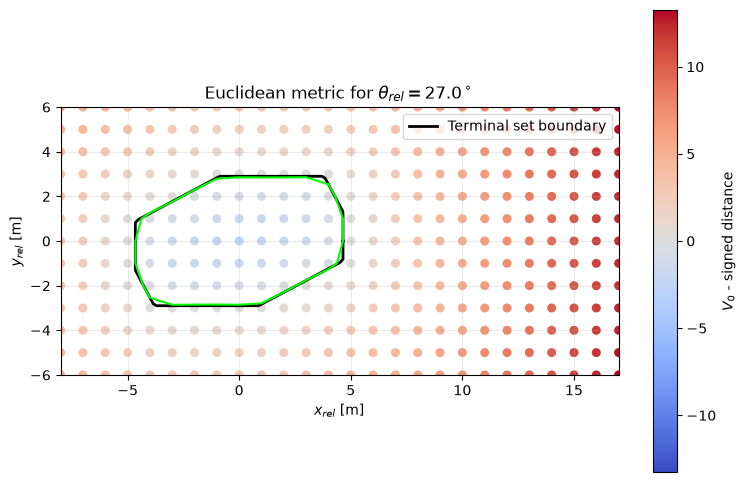

In [4]:
x_axis = np.asarray(grid.coordinate_vectors[0])
y_axis = np.asarray(grid.coordinate_vectors[1])
theta_axis = np.asarray(grid.coordinate_vectors[2])

theta_target = np.deg2rad(30)
i_theta = int(np.argmin(np.abs(theta_axis - theta_target)))
theta_plot = float(theta_axis[i_theta])
V0_slice = V0[:, :, i_theta, 0, 0, 0]
x_plot, y_plot = np.meshgrid(x_axis, y_axis, indexing="ij")

i_boundary = int(np.argmin(np.abs(boundary.theta - theta_plot)))
B_slice = boundary.points[i_boundary]
B_closed = np.vstack((B_slice, B_slice[0]))

value_limit = float(np.max(np.abs(V0_slice)))
norm = TwoSlopeNorm(vmin=-value_limit, vcenter=0.0, vmax=value_limit)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    x_plot.ravel(),
    y_plot.ravel(),
    c=V0_slice.ravel(),
    cmap="coolwarm",
    norm=norm,
    s=42,
    edgecolors="none",
)
ax.plot(B_closed[:, 0], B_closed[:, 1], "k-", linewidth=2.0, label="Terminal set boundary")
ax.contour(x_plot, y_plot, V0_slice, levels=[0.0], colors="lime", linewidths=1.5)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label(r"$V_0$ - signed distance")
ax.set_xlabel(r"$x_{rel}$ [m]")
ax.set_ylabel(r"$y_{rel}$ [m]")
ax.set_title(rf"Euclidean metric for $\theta_{{rel}}={np.rad2deg(theta_plot):.1f}^\circ$")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## 4. Grid for BRT

In [5]:
import hj_reachability as hj

from hj_reachability.systems.relative_vehicle_6d import RelativeVehicle6D

In [7]:
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(
        lo=jnp.array([ -8.0, -6.0, -0.25 * np.pi,  1.0, -np.pi/12, 1.0]),
        hi=jnp.array([ 17.0,  6.0,  0.25 * np.pi, 11.0,  np.pi/12, 11.0]),
    ),
    shape=(26, 13, 15, 11, 11, 11),
    periodic_dims=2,
)

print("Forma della griglia:", grid.shape)
print("Numero di stati:", int(np.prod(grid.shape)))

Forma della griglia: (26, 13, 15, 11, 11, 11)
Numero di stati: 6748170


## 5. Terminal value function

In [8]:
V0 = metricEuclidean(
    grid=grid,
    boundary=boundary,
)

V0_BRT = V0.terminal_values

print("Forma di V0:", V0_BRT.shape)
print("Intervallo di V0:", float(jnp.min(V0_BRT)), float(np.max(V0_BRT)))

Forma di V0: (26, 13, 15, 11, 11, 11)
Intervallo di V0: -3.204360008239746 13.482062339782715


## 6. 6D relative dynamics and solver settings

In [9]:
dynamics = RelativeVehicle6D(
    lf=1.2,
    lr=1.5,
)

solver_settings = hj.SolverSettings.with_accuracy(
    "low",
    hamiltonian_postprocessor=hj.solver.backwards_reachable_tube,
)

## 7. BRT calculation

In [10]:
time = 0.0
target_time = -3.0

BRT = hj.step(
    solver_settings,
    dynamics,
    grid,
    time,
    V0_BRT,
    target_time,
)



100%|##########|  3.0000/3.0 [14:46<00:00, 295.52s/sim_s]


In [11]:
gradienti = grid.grad_values(BRT, solver_settings.upwind_scheme)

print("Forma gradiente:", gradienti.shape)
print("Intervallo gradiente:", float(jnp.min(gradienti)), float(np.max(gradienti)))
print("Forma di BRT:", BRT.shape)
print("Intervallo di BRT:", float(jnp.min(BRT)), float(np.max(BRT)))

Forma gradiente: (26, 13, 15, 11, 11, 11, 6)
Intervallo gradiente: -78.78609466552734 77.43636322021484
Forma di BRT: (26, 13, 15, 11, 11, 11)
Intervallo di BRT: -23.305015563964844 13.482062339782715


## 8. BRT slice
- $\theta_{rel} = 36$ deg
- $v_H = 10$ m/s
- $\delta_E = 0$ rad
- $v_E = 10$ m/s

theta_rel plottato: 27.000006 deg
v_H plottata: 10.0 m/s
delta_E plottato: 0.0 rad
v_E plottata: 10.0 m/s


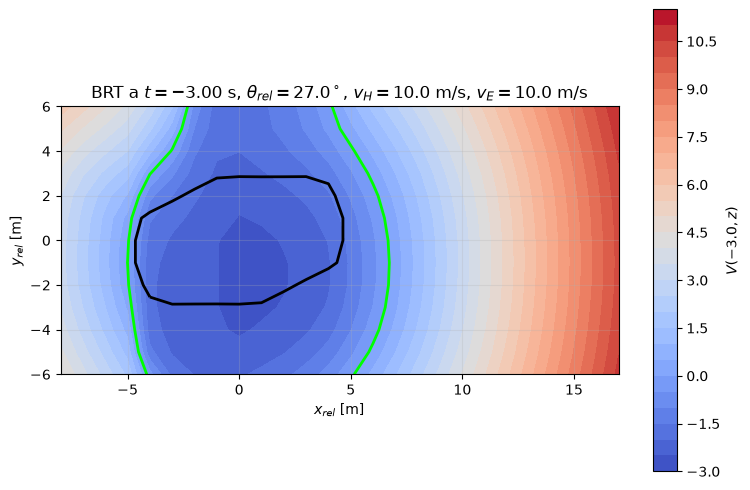

In [12]:
x_axis = np.asarray(grid.coordinate_vectors[0])
y_axis = np.asarray(grid.coordinate_vectors[1])
theta_axis = np.asarray(grid.coordinate_vectors[2])
v_H_axis = np.asarray(grid.coordinate_vectors[3])
delta_E_axis = np.asarray(grid.coordinate_vectors[4])
v_E_axis = np.asarray(grid.coordinate_vectors[5])

theta_target = np.deg2rad(30)
v_H_target = 10.0
delta_E_target = 0.0
v_E_target = 10.0

i_theta = int(np.argmin(np.abs(theta_axis - theta_target)))
i_v_H = int(np.argmin(np.abs(v_H_axis - v_H_target)))
i_delta_E = int(np.argmin(np.abs(delta_E_axis - delta_E_target)))
i_v_E = int(np.argmin(np.abs(v_E_axis - v_E_target)))

V0_plot = np.asarray(
    V0_BRT[:, :, i_theta, i_v_H, i_delta_E, i_v_E]
)

BRT_plot = np.asarray(
    BRT[:, :, i_theta, i_v_H, i_delta_E, i_v_E]
)

print("theta_rel plottato:", np.rad2deg(theta_axis[i_theta]), "deg")
print("v_H plottata:", v_H_axis[i_v_H], "m/s")
print("delta_E plottato:", delta_E_axis[i_delta_E], "rad")
print("v_E plottata:", v_E_axis[i_v_E], "m/s")

fig, ax = plt.subplots(figsize=(9, 6))

contour = ax.contourf(
    x_axis,
    y_axis,
    BRT_plot.T,
    levels=30,
    cmap="coolwarm",
)

fig.colorbar(
    contour,
    ax=ax,
    label=rf"$V({target_time},z)$",
)

# Bordo del terminal set originale: V0 = 0
ax.contour(
    x_axis,
    y_axis,
    V0_plot.T,
    levels=[0.0],
    colors="black",
    linewidths=2.0,
)

# Bordo del BRT propagato: V(-T,z) = 0
ax.contour(
    x_axis,
    y_axis,
    BRT_plot.T,
    levels=[0.0],
    colors="lime",
    linewidths=2.0,
)

ax.set_xlabel(r"$x_{rel}$ [m]")
ax.set_ylabel(r"$y_{rel}$ [m]")
ax.set_title(
    rf"BRT a $t={target_time:.2f}$ s, "
    rf"$\theta_{{rel}}={np.rad2deg(theta_axis[i_theta]):.1f}^\circ$, "
    rf"$v_H={v_H_axis[i_v_H]:.1f}$ m/s, "
    rf"$v_E={v_E_axis[i_v_E]:.1f}$ m/s"
)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)

plt.show()

# 9. 3D BRT plot
For fixed:
- $v_H$
- $\delta_E$
- $v_E$

In [13]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

v_H_target = 10.0
delta_E_target = 0.0
v_E_target = 10.0

i_v_H = int(np.argmin(np.abs(v_H_axis - v_H_target)))
i_delta_E = int(np.argmin(np.abs(delta_E_axis - delta_E_target)))
i_v_E = int(np.argmin(np.abs(v_E_axis - v_E_target)))

BRT_3D = np.asarray(
    BRT[:, :, :, i_v_H, i_delta_E, i_v_E]
)

V0_3D = np.asarray(
    V0_BRT[:, :, :, i_v_H, i_delta_E, i_v_E]
)

print("Forma slice 3D:", BRT_3D.shape)

x_3D, y_3D, theta_3D = np.meshgrid(
    x_axis,
    y_axis,
    theta_axis,
    indexing="ij",
)

fig = go.Figure()

# Terminal set iniziale: V0 = 0
fig.add_trace(
    go.Isosurface(
        x=x_3D.ravel(),
        y=y_3D.ravel(),
        z=np.rad2deg(theta_3D.ravel()),
        value=V0_3D.ravel(),
        isomin=0.0,
        isomax=0.0,
        surface_count=1,
        colorscale=[[0.0, "black"], [1.0, "black"]],
        opacity=0.45,
        caps=dict(x_show=False, y_show=False, z_show=False),
        name="Terminal set",
        showscale=False,
    )
)

# BRT propagato: V(t,z) = 0
fig.add_trace(
    go.Isosurface(
        x=x_3D.ravel(),
        y=y_3D.ravel(),
        z=np.rad2deg(theta_3D.ravel()),
        value=BRT_3D.ravel(),
        isomin=0.0,
        isomax=0.0,
        surface_count=1,
        colorscale=[[0.0, "lime"], [1.0, "lime"]],
        opacity=0.55,
        caps=dict(x_show=False, y_show=False, z_show=False),
        name="BRT",
        showscale=False,
    )
)

fig.update_layout(
    title=(
        f"BRT a t = {target_time:.2f} s — "
        f"v_H = {v_H_axis[i_v_H]:.1f} m/s, "
        f"delta_E = {delta_E_axis[i_delta_E]:.3f} rad, "
        f"v_E = {v_E_axis[i_v_E]:.1f} m/s"
    ),

    scene=dict(
        xaxis=dict(
            title="x_rel [m]",
            backgroundcolor="white",
            gridcolor="lightgray",
        ),
        yaxis=dict(
            title="y_rel [m]",
            backgroundcolor="white",
            gridcolor="lightgray",
        ),
        zaxis=dict(
            title="theta_rel [deg]",
            tickmode="array",
            tickvals=[-180, -90, 0, 90, 180],
            backgroundcolor="white",
            gridcolor="lightgray",
        ),

        # Proporzioni grafiche indipendenti dalle unità fisiche
        aspectmode="manual",
        aspectratio=dict(
            x=1.4,
            y=1.0,
            z=1.2,
        ),

        camera=dict(
            eye=dict(x=1.6, y=1.6, z=1.15),
            up=dict(x=0, y=0, z=1),
        ),
    ),

    width=1000,
    height=750,
    margin=dict(l=20, r=20, b=20, t=70),
)

fig.show()

Forma slice 3D: (26, 13, 15)


## Save BRT

In [16]:
# Salvataggio di BRT, gradienti e griglia

save_dir = project_root / "results"
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "brt_euclidean.npz"

# Conversione degli array JAX in NumPy float32
BRT_save = np.asarray(BRT, dtype=np.float32)
gradienti_save = np.asarray(gradienti, dtype=np.float32)

# Coordinate della griglia 6D
x_rel_save = np.asarray(grid.coordinate_vectors[0], dtype=np.float32)
y_rel_save = np.asarray(grid.coordinate_vectors[1], dtype=np.float32)
theta_rel_save = np.asarray(grid.coordinate_vectors[2], dtype=np.float32)
v_H_save = np.asarray(grid.coordinate_vectors[3], dtype=np.float32)
delta_E_save = np.asarray(grid.coordinate_vectors[4], dtype=np.float32)
v_E_save = np.asarray(grid.coordinate_vectors[5], dtype=np.float32)

# Controlli prima del salvataggio
assert BRT_save.shape == tuple(grid.shape)
assert gradienti_save.shape == (*tuple(grid.shape), 6)

np.savez_compressed(
    save_path,
    BRT=BRT_save,
    gradienti=gradienti_save,
    x_rel=x_rel_save,
    y_rel=y_rel_save,
    theta_rel=theta_rel_save,
    v_H=v_H_save,
    delta_E=delta_E_save,
    v_E=v_E_save,
    target_time=np.float32(target_time),
    periodic_dims=np.asarray([2], dtype=np.int32),
)

print(f"File salvato in: {save_path.resolve()}")
print("Forma BRT:", BRT_save.shape)
print("Forma gradienti:", gradienti_save.shape)
print(f"Dimensione file: {save_path.stat().st_size / 1024**2:.1f} MB")

File salvato in: /home/alessio/TESI/hj_reachability/results/brt_euclidean.npz
Forma BRT: (26, 13, 15, 11, 11, 11)
Forma gradienti: (26, 13, 15, 11, 11, 11, 6)
Dimensione file: 133.3 MB
